# 102 - Resonator Spectroscopy with Python Outer Loop
This version of the resonator spectroscopy uses python for the outer loop which I suspect hinders its speed / total runtime.

\- BSW 6/2026

In [1]:
from qick import *
import numpy as np
import matplotlib.pyplot as plt
import time

soc = QickSoc()
soccfg = soc
print(soccfg)

QICK running on RFSoC2x4, software version 0.2.393

Firmware configuration (built Sun Mar 15 22:07:33 2026):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	DAC output power mode: 20mA

	4 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_D
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 2 is DAC_C
	2:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_B
	3:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=

In [2]:
class SingleFreqProgram(AveragerProgram):
    def __init__(self,soccfg, cfg):
        super().__init__(soccfg, cfg)
        
    def initialize(self):
        cfg=self.cfg   
        
        # configure the readout lengths and downconversion frequencies
        self.declare_readout(ch=self.cfg['readout_ch'], length=self.cfg["readout_length"], freq=self.cfg["pulse_freq"], gen_ch=self.cfg["sig_gen_ch"])

        self.declare_gen(ch=self.cfg['sig_gen_ch'], nqz=1)
        
        freq=soccfg.freq2reg(cfg["pulse_freq"])  # convert frequency to dac frequency
        self.trigger(pins=[0], t=0) # send a pulse on pmod0_0, for scope trigger
        
        self.set_pulse_registers(ch=self.cfg['sig_gen_ch'], style="const", freq=freq, phase=0, gain=cfg["pulse_gain"], 
                                 length=cfg["length"])

        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.measure(pulse_ch=self.cfg["sig_gen_ch"], 
             adcs=[self.cfg["readout_ch"]],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             t=0,
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))

In [3]:
config={"sig_gen_ch": 3,
        "readout_ch": 1,
        "reps": 1, # --Fixed
        "res_phase":soccfg.deg2reg(0), # --Fixed
        
        "length": 5000, # [Clock ticks]
        # Try varying length from 10-100 clock ticks
        
        "readout_length": 1500, # [Clock ticks]
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain": 20000, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "pulse_freq": 90, # [MHz]
        # In this program the signal is up and downconverted digitally so you won't see any frequency
        # components in the I/Q traces below. But since the signal gain depends on frequency, 
        # if you lower pulse_freq you will see an increased gain.

        "adc_trig_offset": 0, # [Clock ticks]
        # Try varying adc_trig_offset from 100 to 220 clock ticks

        "soft_avgs":1,
        # Try varying soft_avgs from 1 to 200 averages
        
        "relax_delay":0 # --copied from below
       }

  0%|          | 0/1 [00:00<?, ?it/s]

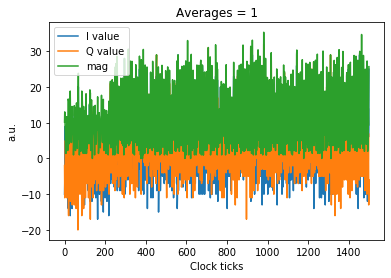

In [4]:
# ToF measurement to calibrate output
prog = SingleFreqProgram(soccfg, config)
iq_list = prog.acquire_decimated(soc, progress=True)# Plot results.
plt.figure(1)
for ii, iq in enumerate(iq_list):
    plt.plot(iq[0], label="I value")
    plt.plot(iq[1], label="Q value")
    plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag")
plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend();
plt.show()

In [5]:
config["adc_trig_offset"] = 250;

# Accumulation on-chip
In order to take advantage of the averaging on-chip, we need to swap functions from the direct "acquire_decimated" function which gives us the raw data, to using the "acquire" function which runs averaging across the whole readout and through repetitions all on the device.

In [9]:
config["readout_length"] = 2000;
config["length"] = 4000; # To prevent early exit
config["pulse_gain"] = 8000; # Lower for safety
config["reps"] = 1000;

f_start=91.9 # MHz
f_stop=92.4 # MHz
expts=1024 # Frequency Points

f_step=(f_stop-f_start)/(expts-1)
print("Freq: " + str(f_start) + "-" + str(f_start+(f_step*(expts-1))))

f_v = np.arange(0,expts)*f_step+f_start
frequency_arr = soccfg.adcfreq(f_v, gen_ch=1, ro_ch=0)

Freq: 91.9-92.4


Runtime: 12.643918 seconds


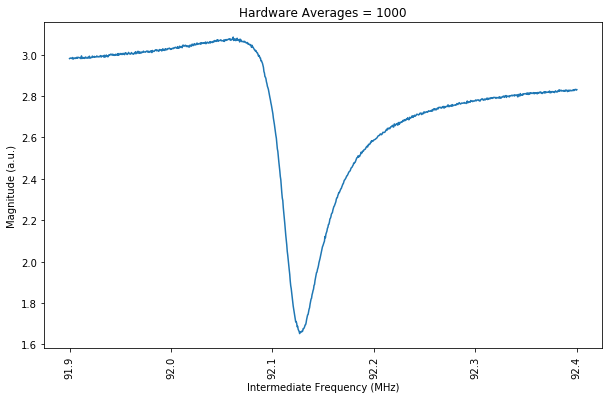

Plot Time: 0.846028 seconds


In [10]:
mag_vec=[]
I_arr = []
Q_arr = []

start_time = time.perf_counter()
for f in frequency_arr:
    config['pulse_freq'] = f
    prog =SingleFreqProgram(soccfg, config)
    #(avg_data,) = prog.acquire_decimated(soc, progress=False)
    #I_mag = (sum(avg_data[0])/config['readout_length'])**2
    #Q_mag = (sum(avg_data[1])/config['readout_length'])**2
    avg_data = prog.acquire(soc, progress=False)
    I = avg_data[0]
    Q = avg_data[1]
    #print(len(I))
    #data = [[prog.di_buf[i]/config['readout_length'], prog.dq_buf[i]/config['readout_length']] for i in [0]]
    #res.append([calculate_phase(d) for d in data])
    #print_results(res[-1], [0] )         
    mag = np.sqrt(I[0]**2 + Q[0]**2)
    mag_vec.append(mag)
    I_arr.append(I)
    Q_arr.append(Q)

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Runtime: {execution_time:.6f} seconds")

start_time = time.perf_counter()

plt.figure(figsize=(10,6))
plt.plot(f_v, mag_vec)
plt.ylabel("Magnitude (a.u.)")
plt.xlabel("Intermediate Frequency (MHz)")
plt.xticks(rotation=90)
plt.title("Hardware Averages = " + str(config["reps"]))
plt.show()

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Plot Time: {execution_time:.6f} seconds")

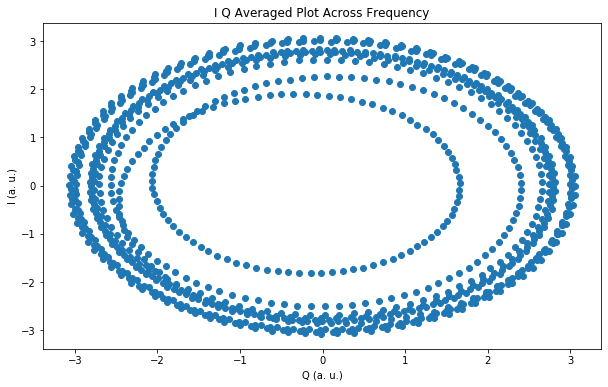

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(I_arr, Q_arr)
plt.ylabel("I (a. u.)")
plt.xlabel("Q (a. u.)")
plt.title("I Q Averaged Plot Across Frequency")
plt.show()

In [13]:
from scipy.io import savemat

savemat("K002_20260626_res_scan.mat", {
    "freq": f_v,
    "I": I_arr,
    "Q": Q_arr,
})